This is a Health care analysis on Stroke in a particular City 

All Visualisations are properly done in power BI

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\HomePC\Downloads\healthcare-dataset-stroke-data%20(1)_MESSED (1).csv")

In [3]:
df.head(6)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,Yes,private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,self-employed,Rural,202.21,NaN,Never Smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,neversmoked,1
3,60182,Female,49.0,0,0,Yes,Private,URBAN,171.23,34.4,smokes,1
4,1665,FEMALE,79.0,1,0,Yes,Self-Employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,yes,PRIVATE,Urban,186.21,29.0,formerly smoked,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns = ["ID",
              "Gender",
              "Age",
              "Hypertension",
              "Heart_Disease",
              "Ever_Married",
              "Work_Type",
              "Residence_Type",
              "Avg_Glucose_Level",
              "BMI",
              "Smoking_Status",
              "Stroke"]

In [9]:
df.columns = (df.columns
      .str.strip()                     
      .str.title()                     
      .str.replace("_", " ") ) 

In [10]:
df.head()

,Id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,9046,male,67.0,0,1,Yes,private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,self-employed,Rural,202.21,NaN,Never Smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,neversmoked,1
3,60182,Female,49.0,0,0,Yes,Private,URBAN,171.23,34.4,smokes,1
4,1665,FEMALE,79.0,1,0,Yes,Self-Employed,Rural,174.12,24.0,never smoked,1


In [11]:
df.columns

Index(['Id', 'Gender', 'Age', 'Hypertension', 'Heart Disease', 'Ever Married',
       'Work Type', 'Residence Type', 'Avg Glucose Level', 'Bmi',
       'Smoking Status', 'Stroke'],
      dtype='object')

In [12]:
df['Gender'].unique()

array(['male', 'Female', 'Male', ' Female', 'FEMALE', 'Female ', 'MALE',
       'female', 'Male ', ' male', ' Male ', ' Male', ' Female ',
       ' female', 'MALE ', ' MALE', ' female ', 'FEMALE ', 'male ',
       ' FEMALE', ' MALE ', 'female ', ' male ', ' FEMALE ', 'Other'],
      dtype=object)

In [13]:
df['Gender'].unique()

array(['male', 'Female', 'Male', ' Female', 'FEMALE', 'Female ', 'MALE',
       'female', 'Male ', ' male', ' Male ', ' Male', ' Female ',
       ' female', 'MALE ', ' MALE', ' female ', 'FEMALE ', 'male ',
       ' FEMALE', ' MALE ', 'female ', ' male ', ' FEMALE ', 'Other'],
      dtype=object)

In [14]:
df['Age'] = df['Age'].astype(int)

In [15]:
df.Age

0       67
1       61
2       80
3       49
4       79
        ..
5105    80
5106    81
5107    35
5108    51
5109    44
Name: Age, Length: 5110, dtype: int64

In [16]:
df['Gender']= df['Gender'].str.strip().str.title()

In [17]:
df['Hypertension'] = df['Hypertension'].replace({0:'No', 1:'Yes'})
df['Heart Disease'] = df['Heart Disease'].replace({0:'No', 1:'Yes'})

In [18]:
df['Ever Married'] = df['Ever Married'].str.title()
df['Work Type'] = df['Work Type'].str.title()
df['Residence Type'] = df['Residence Type'].str.title()
df['Smoking Status'] = df['Smoking Status'].str.title()


In [19]:
df.head()

,Id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,9046,Male,67,No,Yes,Yes,Private,Urban,228.69,36.6,Formerly Smoked,1
1,51676,Female,61,No,No,Yes,Self-Employed,Rural,202.21,NaN,Never Smoked,1
2,31112,Male,80,No,Yes,Yes,Private,Rural,105.92,32.5,Neversmoked,1
3,60182,Female,49,No,No,Yes,Private,Urban,171.23,34.4,Smokes,1
4,1665,Female,79,Yes,No,Yes,Self-Employed,Rural,174.12,24.0,Never Smoked,1


In [20]:
df.head(6)

,Id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,9046,Male,67,No,Yes,Yes,Private,Urban,228.69,36.6,Formerly Smoked,1
1,51676,Female,61,No,No,Yes,Self-Employed,Rural,202.21,NaN,Never Smoked,1
2,31112,Male,80,No,Yes,Yes,Private,Rural,105.92,32.5,Neversmoked,1
3,60182,Female,49,No,No,Yes,Private,Urban,171.23,34.4,Smokes,1
4,1665,Female,79,Yes,No,Yes,Self-Employed,Rural,174.12,24.0,Never Smoked,1
5,56669,Male,81,No,No,Yes,Private,Urban,186.21,29.0,Formerly Smoked,1


In [21]:
df['Hypertension'].unique()

array(['No', 'Yes'], dtype=object)

In [22]:
df['Heart Disease'].unique()

array(['Yes', 'No'], dtype=object)

In [23]:
df['Ever Married'].unique()

array(['Yes', 'No', ' Yes', 'No ', 'Yes ', ' Yes ', ' No', ' No '],
      dtype=object)

In [24]:
df['Ever Married'] = df['Ever Married'].str.strip()

In [25]:
df['Ever Married'].unique()

array(['Yes', 'No'], dtype=object)

In [26]:
df['Work Type'].unique()

array(['Private', 'Self-Employed', 'Private ', 'Govt_Job ',
       ' Self-Employed', 'Govt_Job', ' Private', 'Self-Employed ',
       ' Govt_Job', 'Children', ' Private ', 'Never_Worked',
       ' Self-Employed ', ' Children', 'Children ', ' Govt_Job ',
       ' Children ', 'Never_Worked '], dtype=object)

In [27]:
df['Work Type'] = df['Work Type'].str.strip()

In [28]:
df['Work Type'].unique()

array(['Private', 'Self-Employed', 'Govt_Job', 'Children', 'Never_Worked'],
      dtype=object)

In [29]:
df['Work Type'] = df['Work Type'].str.replace("-", " ")

In [30]:
df['Residence Type'].unique()

array(['Urban', 'Rural', ' Rural', 'Urban ', 'Rural ', ' Urban',
       ' Urban ', ' Rural '], dtype=object)

In [31]:
df['Residence Type'] = df['Residence Type'].str.strip()

In [32]:
df['Residence Type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [33]:
df['Smoking Status'].unique()

array([' Formerly Smoked', 'Never Smoked', 'Neversmoked', 'Smokes',
       'Formerly Smoked', 'Unknown', 'Never Smoked ', ' Smokes',
       ' Never Smoked', 'Formerlysmoked', ' Unknown', 'Formerly Smoked ',
       'Smokes ', ' Never Smoked ', 'Unknown ', ' Unknown ', ' Smokes ',
       ' Formerly Smoked '], dtype=object)

In [34]:
df['Smoking Status'] = df['Smoking Status'].str.strip()

In [35]:
df['Smoking Status'].unique()

array(['Formerly Smoked', 'Never Smoked', 'Neversmoked', 'Smokes',
       'Unknown', 'Formerlysmoked'], dtype=object)

In [36]:
df['Smoking Status'] = df['Smoking Status'].replace({'Formerlysmoked' : 'Formerly Smoked','Neversmoked' : 'Never Smoked'})

In [37]:
df['Smoking Status'].unique()

array(['Formerly Smoked', 'Never Smoked', 'Smokes', 'Unknown'],
      dtype=object)

In [39]:
df.columns = (df.columns.str.replace("Bmi", "BMI") )

In [40]:
df['BMI'].median()

28.1

In [41]:
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

In [42]:
df.BMI.head(3)

0    36.6
1    28.1
2    32.5
Name: BMI, dtype: float64

In [43]:
df['BMI'].isnull().sum()

np.int64(0)

In [45]:
df['Age Group']=pd.cut(df['Age'],
                       bins=[0, 20, 40, 60,100],
                       labels=['Young', 'Adult', 'Middle Aged', 'Above'],
                       include_lowest=True)

In [46]:
df.head()

,Id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,BMI,Smoking Status,Stroke,Age Group
0,9046,Male,67,No,Yes,Yes,Private,Urban,228.69,36.6,Formerly Smoked,1,Above
1,51676,Female,61,No,No,Yes,Self Employed,Rural,202.21,28.1,Never Smoked,1,Above
2,31112,Male,80,No,Yes,Yes,Private,Rural,105.92,32.5,Never Smoked,1,Above
3,60182,Female,49,No,No,Yes,Private,Urban,171.23,34.4,Smokes,1,Middle Aged
4,1665,Female,79,Yes,No,Yes,Self Employed,Rural,174.12,24.0,Never Smoked,1,Above


In [47]:
bins = [0, 18.5, 25, 30, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['BMI Category'] = pd.cut(df['BMI'], bins=bins, labels=labels)

In [48]:
#df['Age Group'] = df['Age Group'].replace({ '0-20': 'Young','21-40': 'Adult', '41-60': 'Middle Aged','Above 60': 'Old'})

In [49]:
df['Age Group'].unique()

['Above', 'Middle Aged', 'Adult', 'Young']
Categories (4, object): ['Young' < 'Adult' < 'Middle Aged' < 'Above']

In [139]:
df.head() 

,Id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,BMI,Smoking Status,Stroke,Age Group,Glucose Level Category
0,9046,Male,67,No,Yes,Yes,Private,Urban,228.69,36.6,Formerly Smoked,1,Old,High
1,51676,Female,61,No,No,Yes,Self Employed,Rural,202.21,28.1,Never Smoked,1,Old,High
2,31112,Male,80,No,Yes,Yes,Private,Rural,105.92,32.5,Never Smoked,1,Old,Normal
3,60182,Female,49,No,No,Yes,Private,Urban,171.23,34.4,Smokes,1,Middle Aged,High
4,1665,Female,79,Yes,No,Yes,Self Employed,Rural,174.12,24.0,Never Smoked,1,Old,High


In [50]:
bins = [0, 70, 140, float('inf')]
labels = ['Low', 'Normal', 'High']
df['Glucose Level Category'] = pd.cut(df['Avg Glucose Level'], bins=bins, labels=labels, include_lowest=True)

In [51]:
df.head()

,Id,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,BMI,Smoking Status,Stroke,Age Group,BMI Category,Glucose Level Category
0,9046,Male,67,No,Yes,Yes,Private,Urban,228.69,36.6,Formerly Smoked,1,Above,Obese,High
1,51676,Female,61,No,No,Yes,Self Employed,Rural,202.21,28.1,Never Smoked,1,Above,Overweight,High
2,31112,Male,80,No,Yes,Yes,Private,Rural,105.92,32.5,Never Smoked,1,Above,Obese,Normal
3,60182,Female,49,No,No,Yes,Private,Urban,171.23,34.4,Smokes,1,Middle Aged,Obese,High
4,1665,Female,79,Yes,No,Yes,Self Employed,Rural,174.12,24.0,Never Smoked,1,Above,Normal,High


In [74]:
df['Stroke'].unique()

array([1, 0])

In [52]:
Stroke_by_Gender = (df.groupby('Gender')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Gender

Gender
Male      5.106383
Female    4.709419
Other     0.000000
Name: Stroke, dtype: float64

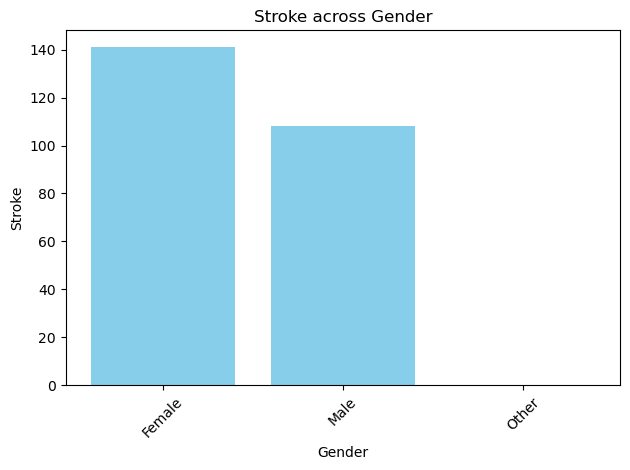

In [53]:
Stroke_by_Gender = df.groupby('Gender')['Stroke'].sum().reset_index()
plt.bar(Stroke_by_Gender['Gender'],Stroke_by_Gender ['Stroke'],color = 'skyblue')
plt.title('Stroke across Gender')
plt.ylabel('Stroke')
plt.xlabel('Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [57]:
Stroke_by_Age_Group =(df.groupby('Age Group')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Age_Group

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4296\2634525798.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Stroke_by_Age_Group =(df.groupby('Age Group')['Stroke'].mean()*100).sort_values(ascending=False)


Age Group
Above          13.573620
Middle Aged     4.097311
Adult           0.492207
Young           0.195122
Name: Stroke, dtype: float64

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4296\2439534178.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Stroke_by_Age_Group = df.groupby('Age Group')['Stroke'].sum().reset_index()


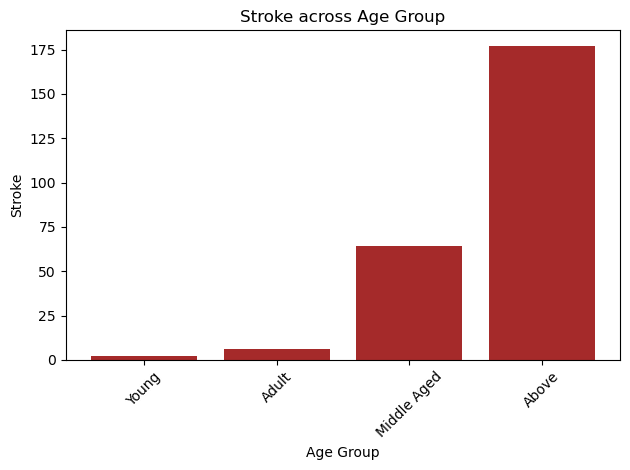

In [54]:
Stroke_by_Age_Group = df.groupby('Age Group')['Stroke'].sum().reset_index()
plt.bar(Stroke_by_Age_Group['Age Group'],Stroke_by_Age_Group ['Stroke'],color = 'brown')
plt.title('Stroke across Age Group')
plt.ylabel('Stroke')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
Stroke_by_Hypertension = (df.groupby('Hypertension')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Hypertension

Hypertension
Yes    13.253012
No      3.967910
Name: Stroke, dtype: float64

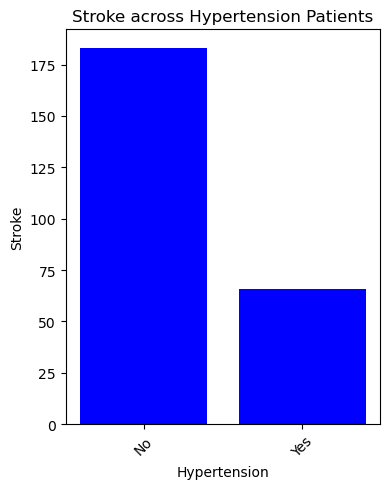

In [59]:
Hypertension = df.groupby('Hypertension')['Stroke'].sum().reset_index()
plt.figure(figsize=(4,5))
plt.bar(Hypertension['Hypertension'],Hypertension ['Stroke'],color = 'blue')
plt.title('Stroke across Hypertension Patients')
plt.ylabel('Stroke')
plt.xlabel('Hypertension')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
Stroke_by_Heart_Disease = (df.groupby('Heart Disease')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Heart_Disease

Heart Disease
Yes    17.028986
No      4.178734
Name: Stroke, dtype: float64

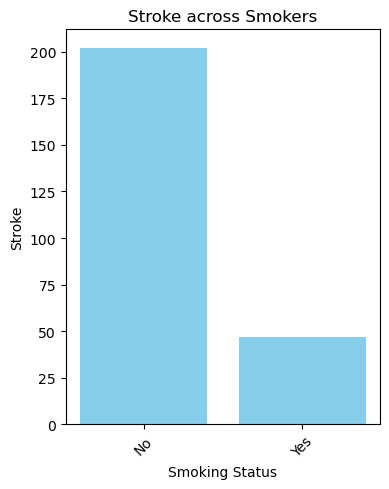

In [61]:
HDS= df.groupby('Heart Disease')['Stroke'].sum().reset_index()
plt.figure(figsize=(4,5))
plt.bar(HDS['Heart Disease'],HDS ['Stroke'],color = 'skyblue')
plt.title('Stroke across Smokers')
plt.ylabel('Stroke')
plt.xlabel('Smoking Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
Stroke_by_Smoking_Status = (df.groupby('Smoking Status')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Smoking_Status

Smoking Status
Formerly Smoked    7.909605
Smokes             5.323194
Never Smoked       4.756871
Unknown            3.044041
Name: Stroke, dtype: float64

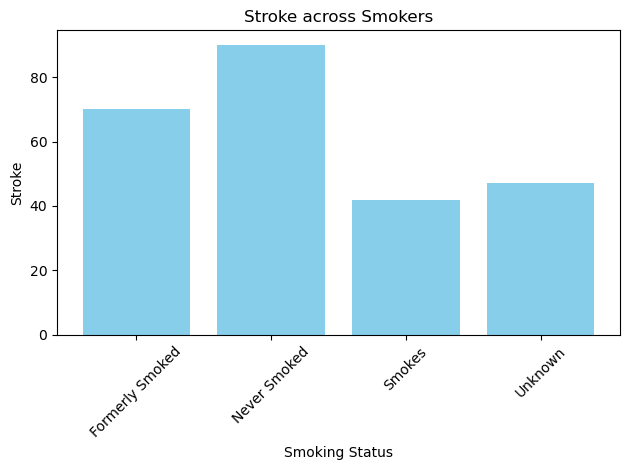

In [63]:
SS= df.groupby('Smoking Status')['Stroke'].sum().reset_index()
plt.bar(SS['Smoking Status'],SS ['Stroke'],color = 'skyblue')
plt.title('Stroke across Smokers')
plt.ylabel('Stroke')
plt.xlabel('Smoking Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
Stroke_by_Glucose_Level = (df.groupby('Glucose Level Category')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Glucose_Level

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4296\1628464157.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Stroke_by_Glucose_Level = (df.groupby('Glucose Level Category')['Stroke'].mean()*100).sort_values(ascending=False)


Glucose Level Category
High      11.327649
Normal     3.651288
Low        3.571429
Name: Stroke, dtype: float64

In [90]:
pd.crosstab(df["Stroke"],
           df["Glucose Level Category"])

Glucose Level Category,Low,Normal,High
Stroke,,,
0,729,3404,728
1,27,129,93


C:\Users\HomePC\AppData\Local\Temp\ipykernel_4296\4107645828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  GLC = df.groupby('Glucose Level Category')['Stroke'].sum().reset_index()


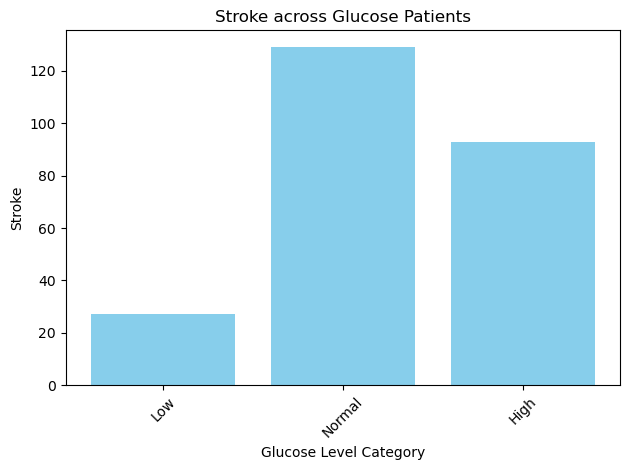

In [65]:
GLC = df.groupby('Glucose Level Category')['Stroke'].sum().reset_index()
plt.bar(GLC['Glucose Level Category'],GLC ['Stroke'],color = 'skyblue')
plt.title('Stroke across Glucose Patients')
plt.ylabel('Stroke')
plt.xlabel('Glucose Level Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [122]:
Stroke_by_BMI = (df.groupby('BMI')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_BMI

BMI
44.1    100.0
36.5     75.0
56.6     50.0
45.7     50.0
42.5     50.0
        ...  
27.6      0.0
26.0      0.0
25.9      0.0
25.7      0.0
97.6      0.0
Name: Stroke, Length: 418, dtype: float64

In [89]:
Stroke_by_Work_Type = (df.groupby('Work Type')['Stroke'].mean()*100).sort_values(ascending=False)
Stroke_by_Work_Type

Work Type
Self Employed    7.936508
Private          5.094017
Govt_Job         5.022831
Children         0.291121
Never_Worked     0.000000
Name: Stroke, dtype: float64

In [87]:
pd.crosstab(df["Stroke"],
            df["Work Type"])

Work Type,Children,Govt_Job,Never_Worked,Private,Self Employed
Stroke,,,,,
0,685,624,22,2776,754
1,2,33,0,149,65


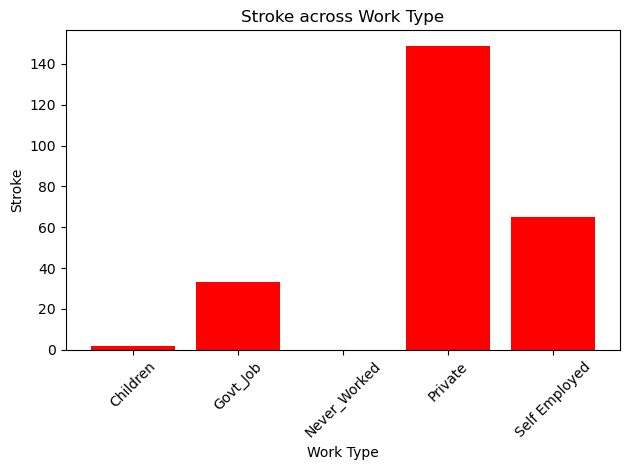

In [141]:
sales_segment = df.groupby('Work Type')['Stroke'].sum().reset_index()
plt.bar(sales_segment['Work Type'],sales_segment ['Stroke'],color = 'red')
plt.title('Stroke across Work Type')
plt.ylabel('Stroke')
plt.xlabel('Work Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
df.to_csv("Cleaned Healthcare Stroke Dataset.csv", index=False)

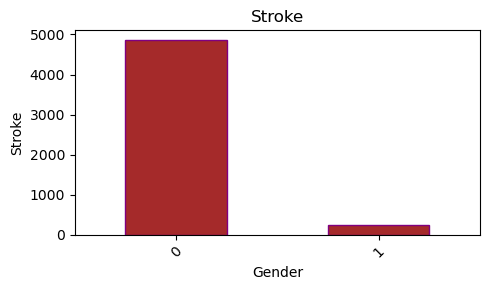

In [81]:
# create a bar chart f0r ship mode
Stroke = df['Stroke'].value_counts()
#for the shape and size
plt.figure(figsize = (5,3))

#for customisation
Gender.plot(kind = 'bar', color = 'brown' ,edgecolor = 'purple')


plt.title('Stroke')
plt.ylabel('Stroke')
plt.xlabel('Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()